# Full End-to-End Pretraining (ChemBL + Zinc + Tox21)
Training supports automatic crash recovery by resuming from the latest checkpoint when `AUTO_RESUME=True`.


This notebook aims to use the pretraining setup from `full_PreTrained_VAE.ipynb` as a starting point architecture for end-to-end model training of the VAE model with a prediction head for Tox21 labels. 

Key dataset change:
- include `tox21_train` in the pretraining train split
- include `tox21_val` in the pretraining validation split
- enforce no canonical-smiles overlap across train/val/test (tox21 split assignment takes priority)
- Property prediction loss incorporated into loss function
- Training end-to-end with prediction head

### Imports and config

In [23]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

try:
    import wandb
except ImportError:
    wandb = None

SEED = 42
MAX_LEN = 120

# ==== DATA SPLIT =====
VAL_FRAC = 0.10
TEST_FRAC = 0.10

# ==== TRAINING CONTROL =====
MIN_EPOCHS = 50
MAX_EPOCHS = 120
EARLY_STOPPING_PATIENCE = 15

# ==== LR SCHEDULER =====
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 10

# ===== CORE MODEL =====
LATENT_DIM = 96
EMBED_DIM = 256
HIDDEN_DIM = 512
NUM_TASKS = 12
DROPOUT = 0.1

# ===== TRAINING =====
BATCH_SIZE = 128
KL_ANNEAL_EPOCHS = 25
FREE_BITS_NATS = 1.0 

# ==========================================
# PHASE CONFIGURATION
# ==========================================
PHASE1_EPOCHS = 50
PHASE1_LR = 3e-4  
PHASE1_RECON_WEIGHT = 1.0

PHASE2_EPOCHS = 80 
PHASE2_LR = 5e-5
PHASE2_PRED_WEIGHT = 1.0
PHASE2_RECON_WEIGHT = 3.0 

# =============================================================================

AUTO_RESUME = False

USE_WANDB = False 
WANDB_PROJECT = "ai-for-toxicology"
WANDB_RUN_NAME = "full-pretrain-chembl-zinc-tox21-seqconv"

# ===== CHECKPOINT SETTINGS =====
# Changed directory name as requested
CHECKPOINT_DIR = Path("artifacts") / "end-to-end_checkpoint"
CHECKPOINT_STEM = "e2evae_full_seqconv_ce"
SAVE_EPOCH_CHECKPOINTS = False  # Set to False to only keep Last/Best per phase
SAVE_EPOCH_CHECKPOINTS = True  # Set False if disk usage becomes too high.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)
print("wandb:", "available" if wandb is not None else "not installed (optional)")

device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1
wandb: available


### Load ChemBL, Zinc, and Tox21 datasets

In [2]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH, TOX21_TRAIN_PATH, TOX21_VAL_PATH, TOX21_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))

TOX21_TASKS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"
]

def load_tox21_labels(path):
    df = pd.read_csv(path)

    y = df[TOX21_TASKS].values.astype(np.float32)
    mask = ~np.isnan(y)

    y = np.nan_to_num(y, nan=0.0)

    return y, mask.astype(np.float32)

y_train_tox21, mask_train_tox21 = load_tox21_labels(TOX21_TRAIN_PATH)
y_val_tox21, mask_val_tox21 = load_tox21_labels(TOX21_VAL_PATH)
y_test_tox21, mask_test_tox21 = load_tox21_labels(TOX21_TEST_PATH) 

print(f"ChemBL unique SMILES:      {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:        {len(zinc_smiles):,}")
print(f"Base pretraining unique:   {len(pretrain_smiles):,}")
print(f"Tox21 train unique SMILES: {len(tox21_train_smiles):,}")
print(f"Tox21 val unique SMILES:   {len(tox21_val_smiles):,}")
print(f"Tox21 test unique SMILES:  {len(tox21_test_smiles):,}") 

ChemBL unique SMILES:      23,871
Zinc unique SMILES:        249,455
Base pretraining unique:   273,321
Tox21 train unique SMILES: 6,258
Tox21 val unique SMILES:   782
Tox21 test unique SMILES:  783


### Create base split, merge Tox21 train/val, enforce split isolation, and convert to SELFIES

In [4]:
def smiles_to_selfies(smiles_list):
    out = []
    kept_smiles = []
    failed = 0
    for smi in smiles_list:
        try:
            sf_str = sf.encoder(smi)
            out.append(sf_str)
            kept_smiles.append(smi)
        except Exception:
            failed += 1
    return out, kept_smiles, failed


def filter_selfies_len(selfies_list: list[str], max_len: int = MAX_LEN) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]


def split_list(items: list[str], val_frac: float, test_frac: float, seed: int) -> tuple[list[str], list[str], list[str]]:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(items))
    rng.shuffle(idx)

    n = len(items)
    n_test = max(1, int(round(n * test_frac)))
    n_val = max(1, int(round(n * val_frac)))

    if n_test + n_val >= n:
        n_test = max(1, n // 10)
        n_val = max(1, n // 10)

    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    train = [items[i] for i in train_idx]
    val = [items[i] for i in val_idx]
    test = [items[i] for i in test_idx]
    return train, val, test


# 1) Base ChemBL+Zinc split (same logic as the original notebook)
base_train_smiles, base_val_smiles, base_test_smiles = split_list(pretrain_smiles, VAL_FRAC, TEST_FRAC, seed=SEED)

# 2) Tox21 Train Set Split
tox21_train_set = set(tox21_train_smiles)
tox21_val_set = set(tox21_val_smiles)
tox21_test_set = set(tox21_test_smiles) # Added this

# Combine all Tox21 into one "forbidden" set
all_tox21_smiles = tox21_train_set | tox21_val_set | tox21_test_set

# Clean all base splits against the ENTIRE Tox21 collection
base_train_smiles = [s for s in base_train_smiles if s not in all_tox21_smiles]
base_val_smiles = [s for s in base_val_smiles if s not in all_tox21_smiles]
base_test_smiles = [s for s in base_test_smiles if s not in all_tox21_smiles]
# --- END OF REPLACEMENT ---


# Pretraining sets (ZINC + ChemBL Only)
pretrain_train_smiles = base_train_smiles
pretrain_val_smiles = base_val_smiles
pretrain_test_smiles = base_test_smiles

# Fine-tuning sets (Tox21 Only)
finetune_train_smiles = tox21_train_smiles
finetune_val_smiles = tox21_val_smiles
finetune_test_smiles = tox21_test_smiles

# 3) Integrity checks (Ensure pretrain and finetune sets are isolated)
pretrain_set = set(pretrain_train_smiles + pretrain_val_smiles + pretrain_test_smiles)
finetune_set = set(finetune_train_smiles + finetune_val_smiles + finetune_test_smiles)

assert pretrain_set.isdisjoint(finetune_set), "Overlap between Pretraining and Tox21 sets detected!"

print("Converting Pre-training SMILES to SELFIES...")
pre_train_selfies, _, _ = smiles_to_selfies(pretrain_train_smiles)
pre_val_selfies, _, _ = smiles_to_selfies(pretrain_val_smiles)

print("Converting Fine-tuning (Tox21) SMILES to SELFIES...")
ft_train_selfies, _, _ = smiles_to_selfies(finetune_train_smiles)
ft_val_selfies, _, _ = smiles_to_selfies(finetune_val_smiles)
ft_test_selfies, _, _ = smiles_to_selfies(finetune_test_smiles)

# Filter lengths for all sets
pre_train_selfies = filter_selfies_len(pre_train_selfies)
pre_val_selfies = filter_selfies_len(pre_val_selfies)
ft_train_selfies = filter_selfies_len(ft_train_selfies)
ft_val_selfies = filter_selfies_len(ft_val_selfies)
ft_test_selfies = filter_selfies_len(ft_test_selfies)


Converting Pre-training SMILES to SELFIES...
Converting Fine-tuning (Tox21) SMILES to SELFIES...


### Tokenization and encoding

In [6]:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"

def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))

# We combine both training sets to build a comprehensive vocabulary
all_training_selfies = pre_train_selfies + ft_train_selfies
train_tokens = [tokenize_selfies(s) for s in all_training_selfies]

vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})

ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

if SEQ_LEN < 29:
    raise ValueError("Sequence length is too small for conv kernels (9, 9, 11).")


def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def encode_list(selfies_list: list[str]) -> np.ndarray:
    out = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out[i, :len(ids)] = ids
    return out

# 1. Encode Pre-training Tensors (No labels needed here)
pre_train_x = encode_list(pre_train_selfies)
pre_val_x = encode_list(pre_val_selfies)

# 2. Encode Fine-tuning Tensors
ft_train_x = encode_list(ft_train_selfies)
ft_val_x = encode_list(ft_val_selfies)
ft_test_x = encode_list(ft_test_selfies)

# 3. Align Tox21 Labels
# Since ft_train_x was built directly from finetune_train_smiles, 
# and the labels match that order, we can use them directly.
y_train_ft, mask_train_ft = y_train_tox21[:len(ft_train_x)], mask_train_tox21[:len(ft_train_x)]
y_val_ft, mask_val_ft = y_val_tox21[:len(ft_val_x)], mask_val_tox21[:len(ft_val_x)]
y_test_ft, mask_test_ft = y_test_tox21[:len(ft_test_x)], mask_test_tox21[:len(ft_test_x)]

print(f"Pre-train: train={pre_train_x.shape}, val={pre_val_x.shape}")
print(f"Fine-tune: train={ft_train_x.shape}, val={ft_val_x.shape}, test={ft_test_x.shape}")
print(f"VOCAB_SIZE={VOCAB_SIZE}, SEQ_LEN={SEQ_LEN}")

Pre-train: train=(218013, 121), val=(27245, 121)
Fine-tune: train=(6237, 121), val=(770, 121), test=(765, 121)
VOCAB_SIZE=204, SEQ_LEN=121


### SELFIES VAE

In [7]:
class VAEDataset(Dataset):
    def __init__(self, x, y=None, mask=None):
        # Always convert x to a LongTensor
        self.x = torch.as_tensor(x).long()
        
        # If y is missing, provide a Zero Tensor of the same length
        # Using NUM_TASKS (12 for Tox21) ensures the shape matches your VAEPredictor head
        if y is None:
            self.y = torch.zeros((len(x), NUM_TASKS), dtype=torch.float32)
        else:
            self.y = torch.as_tensor(y).float()
            
        # Same logic for the mask
        if mask is None:
            self.mask = torch.zeros((len(x), NUM_TASKS), dtype=torch.float32)
        else:
            self.mask = torch.as_tensor(mask).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # This now GUARANTEES that the DataLoader receives three Tensors
        return self.x[idx], self.y[idx], self.mask[idx]

class VAEWithPredictor(nn.Module):
    def __init__(self, vocab_size, seq_len):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, EMBED_DIM)

        # ===== ENCODER =====
        self.encoder = nn.Sequential(
            nn.Conv1d(EMBED_DIM, 256, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=7, padding=3),
            nn.ReLU(),
        )

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=256,
                nhead=8,
                dim_feedforward=512,
                dropout=DROPOUT,
                batch_first=True
            ),
            num_layers=2
        )

        self.fc_mu = nn.Linear(256, LATENT_DIM)
        self.fc_logvar = nn.Linear(256, LATENT_DIM)

        # ===== DECODER =====
        self.decoder_input = nn.Linear(LATENT_DIM, EMBED_DIM)

        self.gru = nn.GRU(
            EMBED_DIM,
            HIDDEN_DIM,
            num_layers=2,
            batch_first=True
        )

        self.output = nn.Linear(HIDDEN_DIM, vocab_size)

        # ===== PREDICTION HEAD =====
        self.pred_head = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, NUM_TASKS)
        )

    def encode(self, x):
        x = self.embedding(x)                 # [B, L, E]
        x = x.transpose(1, 2)                # [B, E, L] for Conv1d
        x = self.encoder(x)
        x = x.transpose(1, 2)                # [B, L, 256]
        
        x = self.transformer(x)              # [B, L, 256]
        
        x = x[:, -1, :] 
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, seq_len):
        x = self.decoder_input(z)
        x = x.unsqueeze(1).repeat(1, seq_len, 1)

        out, _ = self.gru(x)
        logits = self.output(out)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)

        logits = self.decode(z, x.size(1))
        pred = self.pred_head(mu)  # use mu (stable!)

        return logits, mu, logvar, pred


def compute_loss(logits, x, mu, logvar, pred, y, mask, beta):

    # ===== RECON =====
    recon = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        x.view(-1),
        ignore_index=PAD_IDX,
        reduction='sum'
    )

    # ===== KL (with free bits) =====
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = torch.clamp(kl, min=FREE_BITS_NATS)
    kl = kl.sum()

    # ===== PREDICTION =====

    if y is not None and mask.sum() > 0:
        # Calculate weights only if we actually have labeled data in the batch
        num_pos = y.sum(0)
        num_neg = mask.sum(0) - num_pos
        pos_weight = (num_neg + 1e-6) / (num_pos + 1e-6) # Corrected ratio: Neg/Pos
        
        bce = F.binary_cross_entropy_with_logits(
            pred, y, reduction='none', pos_weight=pos_weight
        )
        bce = (bce * mask).sum() / mask.sum().clamp(min=1) 
    else:
        bce = torch.tensor(0.0, device=logits.device)


    if mask.sum() > 0:
        total = (
            RECON_LOSS_WEIGHT * recon +
            beta * kl +
            PRED_LOSS_WEIGHT * bce
        )
    else:
        total = (
            RECON_LOSS_WEIGHT * recon +
            beta * kl
        )

    return total, recon, kl, bce


def kl_beta(epoch):
    return min(1.0, epoch / KL_ANNEAL_EPOCHS)

### Training and evaluation helpers (scheduler, early stopping, checkpointing, auto-resume support)

In [8]:
def make_loader(x, y, mask, batch_size, shuffle):
    return DataLoader(
        VAEDataset(x, y, mask),
        batch_size=batch_size,
        shuffle=shuffle
    )


def init_wandb(*, run_name: str | None = None, epochs: int | None = None, start_epoch: int = 0):
    try:
        import wandb
        if not USE_WANDB:
            return None
    except ImportError:
        return None
    except AttributeError:
        # handles cases where wandb module is broken / incomplete
        print("wandb module not available or broken; skipping logging.")
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        name=run_name or WANDB_RUN_NAME,
        config={
            "seed": SEED,
            "max_len": MAX_LEN,
            "latent_dim": LATENT_DIM,
            "min_epochs": MIN_EPOCHS,
            "max_epochs": epochs if epochs is not None else MAX_EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "kl_anneal_epochs": KL_ANNEAL_EPOCHS,
            "free_bits_nats": FREE_BITS_NATS,
            "lr_scheduler_factor": LR_SCHEDULER_FACTOR,
            "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "start_epoch": start_epoch,
            "vocab_size": VOCAB_SIZE,
            "seq_len": SEQ_LEN,
        },
    )


def run_epoch(model, loader, optimizer=None, epoch=1, pretrain_mode=True):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    metrics = {"total": 0, "recon": 0, "kl": 0, "bce": 0, "acc": 0}
    total_tokens = 0
    beta = kl_beta(epoch)

    for x, y, mask in loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device) 
        
        if is_train: optimizer.zero_grad()
        logits, mu, logvar, pred = model(x)

        # 1. Compute Base VAE Losses
        recon_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), x.view(-1), ignore_index=PAD_IDX, reduction='sum')
        kl_loss = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        kl_loss = torch.clamp(kl_loss, min=FREE_BITS_NATS).sum()

        # 2. Compute Prediction Loss (Only if not in Pretrain Mode)
        bce_loss = torch.tensor(0.0, device=device)
        if not pretrain_mode and y is not None:
            # Note: We use a fixed pos_weight or ignore it for the first few FT epochs to prevent exploding gradients
            bce_loss = F.binary_cross_entropy_with_logits(pred, y, reduction='none')
            bce_loss = (bce_loss * mask).sum() / mask.sum().clamp(min=1)

        # 3. Weighted Total
        if pretrain_mode:
            loss = (RECON_LOSS_WEIGHT * recon_loss) + (beta * kl_loss)
        else:
            # In Fine-tuning, we lower RECON weight slightly to let the labels guide the latent space
            loss = (0.5 * recon_loss) + (beta * kl_loss) + (PRED_LOSS_WEIGHT * bce_loss)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Metrics Tracking
        metrics["total"] += loss.item()
        metrics["recon"] += recon_loss.item()
        metrics["kl"] += kl_loss.item()
        metrics["bce"] += bce_loss.item()
        
        preds = logits.argmax(dim=-1)
        m = (x != PAD_IDX)
        metrics["acc"] += ((preds == x) & m).sum().item()
        total_tokens += m.sum().item()

    return {
        "total": metrics["total"] / len(loader),
        "recon_per_token": metrics["recon"] / total_tokens, # Matches your print statement
        "kl": metrics["kl"] / len(loader),
        "bce": metrics["bce"] / len(loader),
        "token_acc": metrics["acc"] / total_tokens      # Matches your print statement
    }

def evaluate(model, x, y, mask, epoch):
    # Ensure y and mask are NOT None before passing to make_loader
    if y is None:
        y = np.zeros((len(x), NUM_TASKS), dtype=np.float32)
    if mask is None:
        mask = np.zeros((len(x), NUM_TASKS), dtype=np.float32)
        
    loader = make_loader(x, y, mask, BATCH_SIZE, False)
    return run_epoch(model, loader, optimizer=None, epoch=epoch)


def _checkpoint_payload(
    model: nn.Module,
    history: dict,
    *,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    test_metrics: dict | None = None,
):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "epoch": int(epoch),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_total": float(best_val_total) if best_val_total is not None else None,
        "best_val_token_acc": float(best_val_token_acc) if best_val_token_acc is not None else None,
        "epochs_no_improve": int(epochs_no_improve),
        "token_to_idx": TOKEN_TO_IDX,
        "seq_len": SEQ_LEN,
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_LEN,
        "pad_idx": PAD_IDX,
        "unk_idx": UNK_IDX,
        "eos_idx": EOS_IDX,
        "history": history,
        "test_metrics": test_metrics,
        "encoder_layout": "onehot_channels_first_seqconv",
        "decoder_output": "logits",
        "loss_name": "token_cross_entropy_plus_kl",
        "selection_metric": "val_token_acc",
    }


def _save_training_checkpoints(
    model: nn.Module,
    history: dict,
    *,
    save_dir: Path,
    checkpoint_stem: str,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    is_best: bool,
    save_epoch_checkpoints: bool,
):
    payload = _checkpoint_payload(
        model,
        history,
        epoch=epoch,
        best_epoch=best_epoch,
        best_val_total=best_val_total,
        best_val_token_acc=best_val_token_acc,
        epochs_no_improve=epochs_no_improve,
        optimizer=optimizer,
        scheduler=scheduler,
        test_metrics=None,
    )

    last_path = save_dir / f"{checkpoint_stem}_last.pt"
    torch.save(payload, last_path)

    if save_epoch_checkpoints:
        epoch_path = save_dir / f"{checkpoint_stem}_epoch_{epoch:03d}.pt"
        torch.save(payload, epoch_path)

    if is_best:
        best_path = save_dir / f"{checkpoint_stem}_best.pt"
        torch.save(payload, best_path)


def train_model(
    train_x: np.ndarray,
    val_x: np.ndarray,
    y_train: np.ndarray | None = None,   # Added
    mask_train: np.ndarray | None = None, # Added
    y_val: np.ndarray | None = None,      # Added
    mask_val: np.ndarray | None = None,    # Added
    *,
    model: nn.Module | None = None,
    optimizer=None,
    scheduler=None,
    history: dict | None = None,
    start_epoch: int = 0,
    min_epochs: int = MIN_EPOCHS,
    max_epochs: int = MAX_EPOCHS,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
    checkpoint_dir: Path | None = None,
    checkpoint_stem: str | None = None,
    save_epoch_checkpoints: bool = SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name: str | None = None,
    best_epoch: int | None = None,
    best_val_token_acc: float | None = None,
    epochs_no_improve: int = 0,
    pretrain_mode: bool = True, # Added this to pass to run_epoch
):
    if model is None:
        model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    if scheduler is None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=LR_SCHEDULER_FACTOR,
            patience=LR_SCHEDULER_PATIENCE,
            min_lr=1e-6,
        )

    train_loader = make_loader(train_x, y_train, mask_train, BATCH_SIZE, True)
    val_loader   = make_loader(val_x, y_val, mask_val, BATCH_SIZE, False)

    # Ensure full history keys exist
    if history is None:
        history = {
            "beta": [],
            "lr": [],
            "train_total": [],
            "val_total": [],
            "train_recon_per_token": [],
            "val_recon_per_token": [],
            "train_kl": [],
            "val_kl": [],
            "train_token_acc": [],
            "val_token_acc": [],
        }
    else:
        for key in [
            "beta",
            "lr",
            "train_total",
            "val_total",
            "train_recon_per_token",
            "val_recon_per_token",
            "train_kl",
            "val_kl",
            "train_token_acc",
            "val_token_acc",
        ]:
            history.setdefault(key, [])

    if best_val_token_acc is None:
        if history["val_token_acc"]:
            best_idx = int(np.argmax(history["val_token_acc"]))
            best_epoch = best_idx + 1
            best_val_token_acc = float(history["val_token_acc"][best_idx])
        else:
            best_epoch = None
            best_val_token_acc = float("-inf")

    best_val_total = float(np.min(history["val_total"])) if history["val_total"] else float("inf")

    if checkpoint_dir is not None and checkpoint_stem is not None:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

    wandb_run = init_wandb(run_name=wandb_run_name, epochs=max_epochs, start_epoch=start_epoch)

    early_stopped = False
    last_epoch = start_epoch

    if start_epoch >= max_epochs:
        print(f"start_epoch={start_epoch} already reached max_epochs={max_epochs}; skipping training loop.")

    for ep in range(start_epoch + 1, max_epochs + 1):
        beta = kl_beta(ep)
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer, epoch=ep, pretrain_mode=pretrain_mode)
        val_metrics = evaluate(model, val_x, y_val, mask_val, ep) # evaluate already uses run_epoch internally

        scheduler.step(val_metrics["total"]) 
        current_lr = float(optimizer.param_groups[0]["lr"])

        history["beta"].append(beta)
        history["lr"].append(current_lr)
        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])
        
        if val_metrics["total"] < best_val_total:
            best_val_total = float(val_metrics["total"])

        is_best = val_metrics["token_acc"] > (best_val_token_acc + 1e-12)
        if is_best:
            best_val_token_acc = float(val_metrics["token_acc"])
            best_epoch = ep
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"epoch {ep:03d} | beta={beta:.2f} | lr={current_lr:.6f} | "
            f"train total={train_metrics['total']:.4f} | val total={val_metrics['total']:.4f} | "
            f"train recon/tok={train_metrics['recon_per_token']:.4f} | val recon/tok={val_metrics['recon_per_token']:.4f} | "
            f"train acc={train_metrics['token_acc']:.4f} | val acc={val_metrics['token_acc']:.4f}"
            + (" | new best val acc" if is_best else "")
        )

        if checkpoint_dir is not None and checkpoint_stem is not None:
            _save_training_checkpoints(
                model,
                history,
                save_dir=checkpoint_dir,
                checkpoint_stem=checkpoint_stem,
                epoch=ep,
                best_epoch=best_epoch,
                best_val_total=best_val_total,
                best_val_token_acc=best_val_token_acc,
                epochs_no_improve=epochs_no_improve,
                optimizer=optimizer,
                scheduler=scheduler,
                is_best=is_best,
                save_epoch_checkpoints=save_epoch_checkpoints,
            )

        if wandb_run is not None:
            wandb_run.log(
                {
                    "epoch": ep,
                    "beta": beta,
                    "lr": current_lr,
                    "train/total": train_metrics["total"],
                    "val/total": val_metrics["total"],
                    "train/recon_per_token": train_metrics["recon_per_token"],
                    "val/recon_per_token": val_metrics["recon_per_token"],
                    "train/kl": train_metrics["kl"],
                    "val/kl": val_metrics["kl"],
                    "train/token_acc": train_metrics["token_acc"],
                    "val/token_acc": val_metrics["token_acc"],
                    "best/val_total": best_val_total,
                    "best/val_token_acc": best_val_token_acc,
                    "best/epoch": best_epoch,
                    "early_stop/epochs_no_improve": epochs_no_improve,
                },
                step=ep,
            )

        last_epoch = ep

        if ep >= min_epochs and epochs_no_improve >= early_stopping_patience:
            early_stopped = True
            print(
                f"Early stopping at epoch {ep}: no val token-accuracy improvement for "
                f"{epochs_no_improve} epochs (patience={early_stopping_patience})."
            )
            break

    if wandb_run is not None:
        wandb_run.finish()

    checkpoint_info = {
        "best_epoch": best_epoch,
        "best_val_total": best_val_total,
        "best_val_token_acc": best_val_token_acc,
        "last_epoch": last_epoch,
        "epochs_no_improve": epochs_no_improve,
        "early_stopped": early_stopped,
    }
    return model, optimizer, scheduler, history, checkpoint_info

### Train the full pretraining model (ChemBL + Zinc + tox21 train, with tox21 val-augmented validation)

In [9]:
def load_checkpoint(path, model, optimizer=None, scheduler=None):
    """Loads a saved checkpoint and returns history and start_epoch."""
    print(f"Loading checkpoint from: {path}")
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer and checkpoint["optimizer_state_dict"]:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scheduler and checkpoint["scheduler_state_dict"]:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    return checkpoint.get("history", None), checkpoint.get("epoch", 0)

In [25]:
# ==========================================
# EXPERIMENT CONTROL
# ==========================================
SKIP_PHASE1 = True  # Set to True to jump straight to Phase 2 using Phase 1 weights
AUTO_RESUME = False 

# Update directory and stem
CHECKPOINT_DIR = Path("artifacts") / "end-to-end_checkpoint"
CHECKPOINT_STEM = "paper_like_selfies_full_pretrain_seqconv_ce"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Initialize Model
model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
history = {} 
start_epoch = 0

# --- SMART RESUME / JUMP LOGIC ---
phase2_last = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase2_last.pt"
phase1_last = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase1_last.pt"

# Priority 1: Resume an existing Phase 2 run
if AUTO_RESUME and phase2_last.exists():
    print(">>> Resuming from existing Phase 2 checkpoint...")
    history, start_epoch = load_checkpoint(phase2_last, model)
    current_phase = 2

# Priority 2: Jump from finished Phase 1 into a new Phase 2
elif SKIP_PHASE1 and phase1_last.exists():
    print(">>> SKIP_PHASE1 active. Loading Phase 1 weights to START Phase 2...")
    history, start_epoch = load_checkpoint(phase1_last, model) 
    start_epoch = PHASE1_EPOCHS # Force start at end of Phase 1
    current_phase = 2

# Priority 3: Start from scratch
else:
    print(">>> No checkpoints found or Phase 1 required. Starting from scratch.")
    current_phase = 1

# ---------------------------------------------------------
# PHASE 1: PRE-TRAINING (Reconstruction Only)
# ---------------------------------------------------------
if current_phase == 1:
    RECON_LOSS_WEIGHT = PHASE1_RECON_WEIGHT
    PRED_LOSS_WEIGHT = 0.0

    print(f"\n>>> RUNNING PHASE 1: Pre-training (ZINC + ChemBL)")
    model, optimizer, scheduler, history, info1 = train_model(
        pre_train_x, pre_val_x,
        y_train=None, mask_train=None, 
        y_val=None, mask_val=None,
        model=model, 
        optimizer=torch.optim.Adam(model.parameters(), lr=PHASE1_LR), 
        scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min"),
        history=history,
        max_epochs=PHASE1_EPOCHS,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"{CHECKPOINT_STEM}_phase1",
        pretrain_mode=True
    )
    start_epoch = info1["last_epoch"]
    current_phase = 2 

# ---------------------------------------------------------
# PHASE 2: FINE-TUNING (Reconstruction + Prediction)
# ---------------------------------------------------------
if current_phase == 2:
    print(f"\n>>> RUNNING PHASE 2: Fine-tuning (Tox21 Only)")
    
    # STABILITY FIXES: Prevent the Accuracy Crash seen at Epoch 50
    # Match the LR to the end of Phase 1 instead of jumping to 1e-4
    PHASE2_LR_STABLE = 5e-5 
    RECON_LOSS_WEIGHT = 3.0  # Anchor the chemical grammar
    PRED_LOSS_WEIGHT = 2.0   # Introduce toxicity head gently

    # Re-initialize optimizer/scheduler specifically for Phase 2
    optimizer = torch.optim.Adam(model.parameters(), lr=PHASE2_LR_STABLE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=15
    )
    
    model, optimizer, scheduler, history, info2 = train_model(
        ft_train_x, ft_val_x,
        y_train=y_train_ft,
        mask_train=mask_train_ft,
        y_val=y_val_ft,
        mask_val=mask_val_ft,
        model=model, 
        optimizer=optimizer, 
        scheduler=scheduler,
        history=history, 
        start_epoch=start_epoch,
        max_epochs=PHASE1_EPOCHS + PHASE2_EPOCHS,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"{CHECKPOINT_STEM}_phase2",
        pretrain_mode=False # Activate the Toxicity predictor
    )
    
    _save_training_checkpoints(
        model, history, 
        save_dir=CHECKPOINT_DIR, 
        checkpoint_stem=f"{CHECKPOINT_STEM}_phase2",
        epoch=info2["last_epoch"], 
        best_epoch=info2["best_epoch"],
        best_val_total=info2["best_val_total"], 
        best_val_token_acc=info2["best_val_token_acc"],
        optimizer=optimizer, 
        scheduler=scheduler,
        is_best=True
    )

# ---------------------------------------------------------
# FINAL EVALUATION
# ---------------------------------------------------------
final_epoch = info2["last_epoch"] if 'info2' in locals() else start_epoch
test_metrics = evaluate(model, ft_test_x, y_test_ft, mask_test_ft, final_epoch, pretrain_mode=False)

print("\nFinal Tox21 Test Metrics:")
for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}") if isinstance(value, float) else print(f"{metric:15s}: {value}")

>>> SKIP_PHASE1 active. Loading Phase 1 weights to START Phase 2...
Loading checkpoint from: artifacts\end-to-end_checkpoint\paper_like_selfies_full_pretrain_seqconv_ce_phase1_last.pt


C:\Users\Taha\AppData\Local\Temp\ipykernel_7188\459705961.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)



>>> RUNNING PHASE 2: Fine-tuning (Tox21 Only)
epoch 051 | beta=1.00 | lr=0.000050 | train total=15212.1128 | val total=32567.9980 | train recon/tok=1.3118 | val recon/tok=1.4949 | train acc=0.6447 | val acc=0.5699 | new best val acc
epoch 052 | beta=1.00 | lr=0.000050 | train total=14997.3257 | val total=32459.8501 | train recon/tok=1.2544 | val recon/tok=1.4899 | train acc=0.6520 | val acc=0.5709 | new best val acc
epoch 053 | beta=1.00 | lr=0.000050 | train total=14893.1787 | val total=32659.9185 | train recon/tok=1.2233 | val recon/tok=1.5055 | train acc=0.6571 | val acc=0.5638
epoch 054 | beta=1.00 | lr=0.000050 | train total=14821.2110 | val total=32294.2739 | train recon/tok=1.2018 | val recon/tok=1.4802 | train acc=0.6592 | val acc=0.5695
epoch 055 | beta=1.00 | lr=0.000050 | train total=14787.0078 | val total=33599.1448 | train recon/tok=1.1948 | val recon/tok=1.5720 | train acc=0.6593 | val acc=0.5368
epoch 056 | beta=1.00 | lr=0.000050 | train total=14763.1197 | val total=32

TypeError: _save_training_checkpoints() missing 2 required keyword-only arguments: 'epochs_no_improve' and 'save_epoch_checkpoints'

In [19]:
# Use the 'ft' (fine-tuning) variables we defined for Tox21
# We use the 'test' set here for the final final evaluation
test_metrics = evaluate(
    model, 
    ft_test_x,     # Updated name
    y_test_ft,     # Updated name
    mask_test_ft,  # Updated name
    final_epoch
)

print("\nFinal Tox21 Test Metrics:")
for metric, value in test_metrics.items():
    if isinstance(value, float):
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: {value}")


Final Tox21 Test Metrics:
total          : 15647.8475
recon_per_token: 1.6249
kl             : 6916.5129
bce            : 0.0000
token_acc      : 0.5241


In [9]:
# 1. Load the checkpoint
checkpoint_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase2_last.pt"
checkpoint = torch.load(checkpoint_path)

# 2. Rebuild the model and load weights
model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

# 3. Run evaluation (using the corrected VAEDataset logic)
# Note: Pass None or actual test labels; the Dataset class handles the tensors now
test_metrics = evaluate(model, test_x, None, None, checkpoint['epoch'])
print("\nFinal Test Metrics:", test_metrics)

C:\Users\Taha\AppData\Local\Temp\ipykernel_11828\4161471906.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


FileNotFoundError: [Errno 2] No such file or directory: 'artifacts\\full_pretraining_checkpoints\\paper_like_selfies_full_pretrain_seqconv_ce_phase2_last.pt'

### Plot training curves

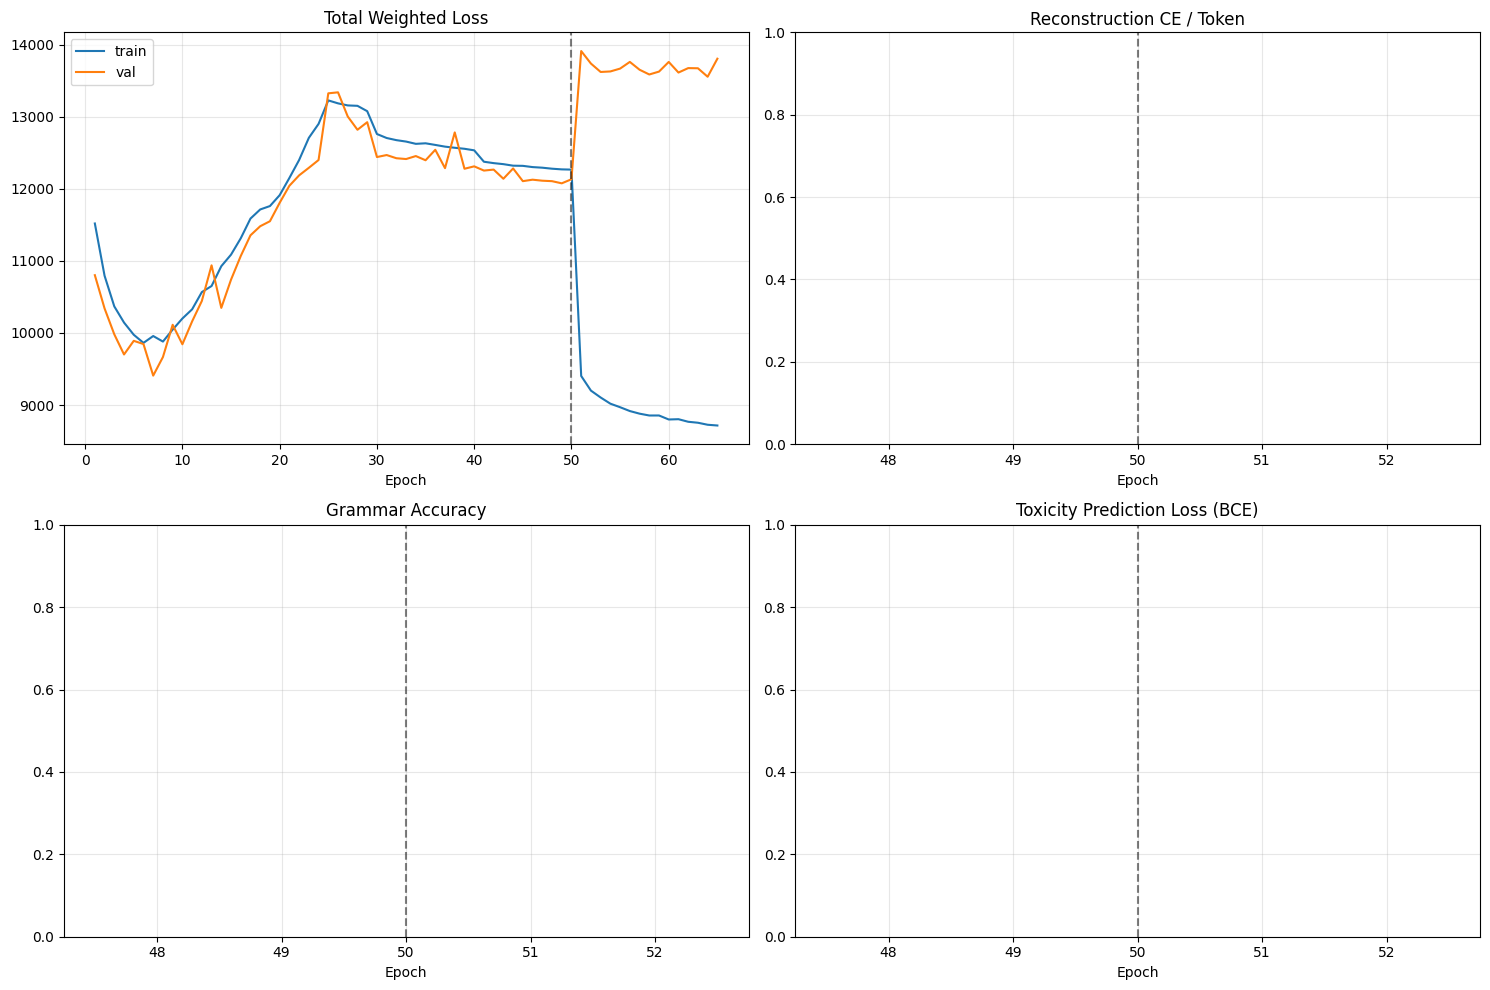

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Helper to safely get history length
# Use 'train_total' as the anchor since it should always exist if training ran
all_keys = history.keys()
max_len = len(history["train_total"]) if "train_total" in history else 0
epochs = np.arange(1, max_len + 1)

if max_len == 0:
    print("Error: History is empty. Check if your train_model function is returning data.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    # Define the metrics we want to plot
    # Format: (Key in history, Title, Axis Index)
    metrics_to_plot = [
        ("train_total", "val_total", "Total Weighted Loss", 0),
        ("train_recon_per_token", "val_recon_per_token", "Reconstruction CE / Token", 1),
        ("train_token_acc", "val_token_acc", "Grammar Accuracy", 2),
        ("train_bce", "val_bce", "Toxicity Prediction Loss (BCE)", 3)
    ]

    for train_key, val_key, title, ax_idx in metrics_to_plot:
        ax = axes[ax_idx]
        
        # Check if the keys exist and have data
        train_data = history.get(train_key, [])
        val_data = history.get(val_key, [])
        
        if len(train_data) == max_len:
            ax.plot(epochs, train_data, label="train")
        if len(val_data) == max_len:
            ax.plot(epochs, val_data, label="val")
            
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        if ax_idx == 0: ax.legend()
        
        # Add the Phase 2 divider
        if max_len > PHASE1_EPOCHS:
            ax.axvline(x=PHASE1_EPOCHS, color='black', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

### Quick reconstruction check

In [9]:
def decode_ids_to_selfies(ids: np.ndarray | list[int]) -> str:
    toks = []
    for idx in ids:
        tok = IDX_TO_TOKEN[int(idx)]
        if tok == EOS:
            break
        if tok == PAD:
            continue
        toks.append(tok)
    return "".join(toks)


def show_reconstructions(n: int = 5, seed: int = 42):
    model.eval()

    rng = np.random.default_rng(seed)
    k = min(n, len(test_x))
    idxs = rng.choice(len(test_x), size=k, replace=False)

    x_ids = torch.from_numpy(test_x[idxs]).long().to(device)
    x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

    with torch.no_grad():
        logits, _, _ = model(x_onehot)
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

    for j, idx in enumerate(idxs):
        orig_selfies = test_selfies[idx]
        pred_selfies = decode_ids_to_selfies(pred_ids[j])
        exact = orig_selfies == pred_selfies
        print(f"[{j}] exact={exact}")
        print("orig:", orig_selfies)
        print("pred:", pred_selfies)
        print()


show_reconstructions(n=5, seed=SEED)


[0] exact=False
orig: [N][N][C][=Branch1][C][=O][C][C][=N][N][=C][Branch1][C][N][S][Ring1][=Branch1]
pred: [C][N][C][=Branch1][C][=O][C][C][=N][N][=C][Branch1][C][N][=N][Ring1][=Branch1]

[1] exact=False
orig: [C][C][=C][C][=C][C][Branch1][C][C][=C][Ring1][#Branch1][C][=C][C][Branch1][C][C][=C][N][=C][Branch2][Ring1][=Branch1][N][C][=C][C][=C][Branch1][O][O][C][C][N][C][C][C][C][Ring1][Branch1][C][=C][Ring1][=C][N][=N][C][Ring2][Ring1][Branch1][=C][Ring2][Ring1][#Branch2]
pred: [C][C][=C][C][=C][C][Branch1][C][C][=C][Ring1][#Branch1][C][=C][C][Branch1][C][C][=C][N][=C][Branch2][Ring1][=Branch1][N][C][=C][C][=C][Branch1][O][O][C][C][N][C][C][C][C][Ring1][Branch1][C][=C][Ring1][P][C][NH1][C][Ring2][Ring1][Branch1][=C][Ring2][Ring1][#Branch2]

[2] exact=True
orig: [C][C][=N][C][Branch2][Ring1][Ring1][C][=Branch1][C][=O][N][C][C@@H1][Branch1][C][C][C][C@H1][Branch1][C][NH3+1][C][Ring1][Branch2][=C][S][Ring1][#C]
pred: [C][C][=N][C][Branch2][Ring1][Ring1][C][=Branch1][C][=O][N][C][C@@H1][Br

### Notes for downstream tox21 classification
- The best checkpoint is selected using **validation token accuracy** (`*_best.pt`).
- The latest checkpoint (`*_last.pt`) is updated every epoch and contains optimizer/scheduler/history state for crash recovery.

### Crash-resume behavior
With `AUTO_RESUME=True`, the main training cell above will resume automatically from `*_last.pt` if present.

# Tox21 downstream evaluation

## XGBoost on tox21 latent features (train on tox21 train, report val/test AUROC + AUPRC)

In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

TOX21_TRAIN_PATH = Path("data") / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = Path("data") / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = Path("data") / "Test" / "tox21_test_clean.csv"

best_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"
if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

bundle = torch.load(best_ckpt_path, map_location=device)
model_best = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
model_best.load_state_dict(bundle["model_state_dict"])
model_best.eval()

TASKS = [c for c in pd.read_csv(TOX21_TRAIN_PATH, nrows=1).columns if c.startswith("NR-") or c.startswith("SR-")]


def _smiles_to_ids_for_vocab(smiles: str):
    try:
        s = sf.encoder(smiles)
        toks = list(sf.split_selfies(s))
    except Exception:
        return None

    if len(toks) > MAX_LEN:
        return None

    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in toks[:MAX_LEN]]
    ids.append(EOS_IDX)

    arr = np.full(SEQ_LEN, PAD_IDX, dtype=np.int64)
    arr[:len(ids)] = ids
    return arr


def build_latent_split(csv_path: Path, task_cols: list[str], batch_size: int = 512):
    df = pd.read_csv(csv_path).dropna(subset=["canonical_smiles"]).reset_index(drop=True)
    y_all = df[task_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

    x_ids_list, y_kept = [], []
    failed = 0
    for smi, y in zip(df["canonical_smiles"].astype(str).tolist(), y_all):
        ids = _smiles_to_ids_for_vocab(smi)
        if ids is None:
            failed += 1
            continue
        x_ids_list.append(ids)
        y_kept.append(y)

    x_ids = np.stack(x_ids_list)
    y = np.stack(y_kept)

    z_chunks = []
    with torch.no_grad():
        for i in range(0, len(x_ids), batch_size):
            xb = torch.from_numpy(x_ids[i:i + batch_size]).long().to(device)
            x_onehot_seq_vocab = F.one_hot(xb, num_classes=VOCAB_SIZE).float()
            x_onehot_vocab_seq = x_onehot_seq_vocab.transpose(1, 2).contiguous()
            mean, _ = model_best.encoder(x_onehot_vocab_seq)
            z_chunks.append(mean.cpu().numpy())

    z = np.vstack(z_chunks)
    return z, y, failed


Z_train, Y_train, fail_train = build_latent_split(TOX21_TRAIN_PATH, TASKS)
Z_val, Y_val, fail_val = build_latent_split(TOX21_VAL_PATH, TASKS)
Z_test, Y_test, fail_test = build_latent_split(TOX21_TEST_PATH, TASKS)

print("Loaded latent feature matrices:")
print(f"train: Z={Z_train.shape}, Y={Y_train.shape}, skipped={fail_train}")
print(f"val  : Z={Z_val.shape}, Y={Y_val.shape}, skipped={fail_val}")
print(f"test : Z={Z_test.shape}, Y={Y_test.shape}, skipped={fail_test}")

Loaded latent feature matrices:
train: Z=(6237, 292), Y=(6237, 12), skipped=21
val  : Z=(770, 292), Y=(770, 12), skipped=12
test : Z=(765, 292), Y=(765, 12), skipped=18


In [11]:
def _binary_metrics(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> dict:
    y_true = y_true.astype(int)
    y_hat = (probs >= threshold).astype(int)

    out = {
        "n": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_hat)) if len(y_true) else np.nan,
        "F1": float(f1_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Precision": float(precision_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Recall": float(recall_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "AUROC": np.nan,
        "AUPRC": np.nan,
    }

    if len(y_true) and len(np.unique(y_true)) >= 2:
        out["AUROC"] = float(roc_auc_score(y_true, probs))
        out["AUPRC"] = float(average_precision_score(y_true, probs))

    return out


task_rows = []
roc_curves = {}
pr_curves = {}

for j, task in enumerate(TASKS):
    ytr, yv, yt = Y_train[:, j], Y_val[:, j], Y_test[:, j]

    mtr = np.isin(ytr, [0, 1])
    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    # Need both classes for training.
    if len(np.unique(ytr[mtr])) < 2:
        continue

    clf = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    )

    fit_kwargs = {"verbose": False}
    if int(mv.sum()) > 0:
        fit_kwargs["eval_set"] = [(Z_val[mv], yv[mv])]

    clf.fit(Z_train[mtr], ytr[mtr], **fit_kwargs)

    if int(mv.sum()) > 0:
        p_val = clf.predict_proba(Z_val[mv])[:, 1]
        y_val = yv[mv].astype(int)
    else:
        p_val = np.array([])
        y_val = np.array([], dtype=int)

    if len(y_val) and len(np.unique(y_val)) >= 2:
        thresholds = np.linspace(0.05, 0.95, 19)
        best_t = max(
            thresholds,
            key=lambda t: f1_score(y_val, (p_val >= t).astype(int), zero_division=0),
        )
    else:
        best_t = 0.5

    p_test = clf.predict_proba(Z_test[mt])[:, 1] if int(mt.sum()) > 0 else np.array([])
    y_test = yt[mt].astype(int) if int(mt.sum()) > 0 else np.array([], dtype=int)

    val_res = _binary_metrics(y_val, p_val, best_t) if len(y_val) else {k: np.nan for k in ["n", "AUROC", "AUPRC", "Accuracy", "F1", "Precision", "Recall"]}
    test_res = _binary_metrics(y_test, p_test, best_t) if len(y_test) else {k: np.nan for k in ["n", "AUROC", "AUPRC", "Accuracy", "F1", "Precision", "Recall"]}

    task_rows.append(
        {
            "task": task,
            "threshold": float(best_t),
            "n_val": int(val_res["n"]) if not np.isnan(val_res["n"]) else 0,
            "Val_AUROC": val_res["AUROC"],
            "Val_AUPRC": val_res["AUPRC"],
            "Val_Accuracy": val_res["Accuracy"],
            "Val_F1": val_res["F1"],
            "Val_Precision": val_res["Precision"],
            "Val_Recall": val_res["Recall"],
            "n_test": int(test_res["n"]) if not np.isnan(test_res["n"]) else 0,
            "Test_AUROC": test_res["AUROC"],
            "Test_AUPRC": test_res["AUPRC"],
            "Test_Accuracy": test_res["Accuracy"],
            "Test_F1": test_res["F1"],
            "Test_Precision": test_res["Precision"],
            "Test_Recall": test_res["Recall"],
        }
    )

    # Keep plotting dictionaries on the tox21 test split for comparability.
    if len(y_test) and len(np.unique(y_test)) >= 2:
        fpr, tpr, _ = roc_curve(y_test, p_test)
        prec, rec, _ = precision_recall_curve(y_test, p_test)
        roc_curves[task] = (fpr, tpr, float(test_res["AUROC"]))
        pr_curves[task] = (rec, prec, float(test_res["AUPRC"]), float(y_test.mean()))

if task_rows:
    metrics_df = pd.DataFrame(task_rows).sort_values("Test_AUROC", ascending=False).reset_index(drop=True)
else:
    metrics_df = pd.DataFrame(
        columns=[
            "task",
            "threshold",
            "n_val",
            "Val_AUROC",
            "Val_AUPRC",
            "Val_Accuracy",
            "Val_F1",
            "Val_Precision",
            "Val_Recall",
            "n_test",
            "Test_AUROC",
            "Test_AUPRC",
            "Test_Accuracy",
            "Test_F1",
            "Test_Precision",
            "Test_Recall",
        ]
    )
metrics_df

,task,threshold,n_val,Val_AUROC,Val_AUPRC,Val_Accuracy,Val_F1,Val_Precision,Val_Recall,n_test,Test_AUROC,Test_AUPRC,Test_Accuracy,Test_F1,Test_Precision,Test_Recall
0,NR-AR-LBD,0.05,770,0.717960,0.241609,0.954545,0.285714,0.291667,0.280000,765,0.797869,0.350472,0.955556,0.320000,0.258065,0.421053
1,NR-AhR,0.05,770,0.674189,0.276932,0.690909,0.283133,0.191837,0.540230,765,0.701275,0.251607,0.705882,0.307692,0.213675,0.549451
2,NR-AR,0.05,770,0.690209,0.227160,0.940260,0.323529,0.297297,0.354839,765,0.684757,0.319822,0.930719,0.273973,0.208333,0.400000
3,NR-ER,0.15,770,0.704497,0.307056,0.868831,0.312925,0.310811,0.315068,765,0.677188,0.264558,0.879739,0.303030,0.312500,0.294118
4,SR-ATAD5,0.15,770,0.590765,0.069571,0.950649,0.050000,0.142857,0.030303,765,0.675648,0.102169,0.954248,0.000000,0.000000,0.000000
5,SR-HSE,0.05,770,0.522759,0.075484,0.925974,0.095238,0.157895,0.068182,765,0.653381,0.107618,0.918954,0.088235,0.142857,0.063830
6,SR-MMP,0.05,770,0.601868,0.199501,0.561039,0.277778,0.181058,0.596330,765,0.636189,0.165527,0.573856,0.272321,0.172316,0.648936
7,SR-p53,0.05,770,0.598514,0.160424,0.884416,0.082474,0.166667,0.054795,765,0.634868,0.141618,0.886275,0.103093,0.161290,0.075758
8,NR-ER-LBD,0.15,770,0.692514,0.254338,0.967532,0.285714,0.555556,0.192308,765,0.593766,0.118032,0.972549,0.086957,0.500000,0.047619
9,NR-Aromatase,0.05,770,0.653644,0.107094,0.927273,0.096774,0.166667,0.068182,765,0.571143,0.078637,0.908497,0.054054,0.071429,0.043478


In [12]:
if metrics_df.empty:
    print("No tox21 tasks had sufficient class variation for train/val/test evaluation.")
else:
    print("Macro average metrics (validation + test):")
    metrics_df[
        [
            "Val_AUROC",
            "Val_AUPRC",
            "Val_Accuracy",
            "Test_AUROC",
            "Test_AUPRC",
            "Test_Accuracy",
        ]
    ].mean(numeric_only=True).to_frame("macro_mean").T

Macro average metrics (validation + test):


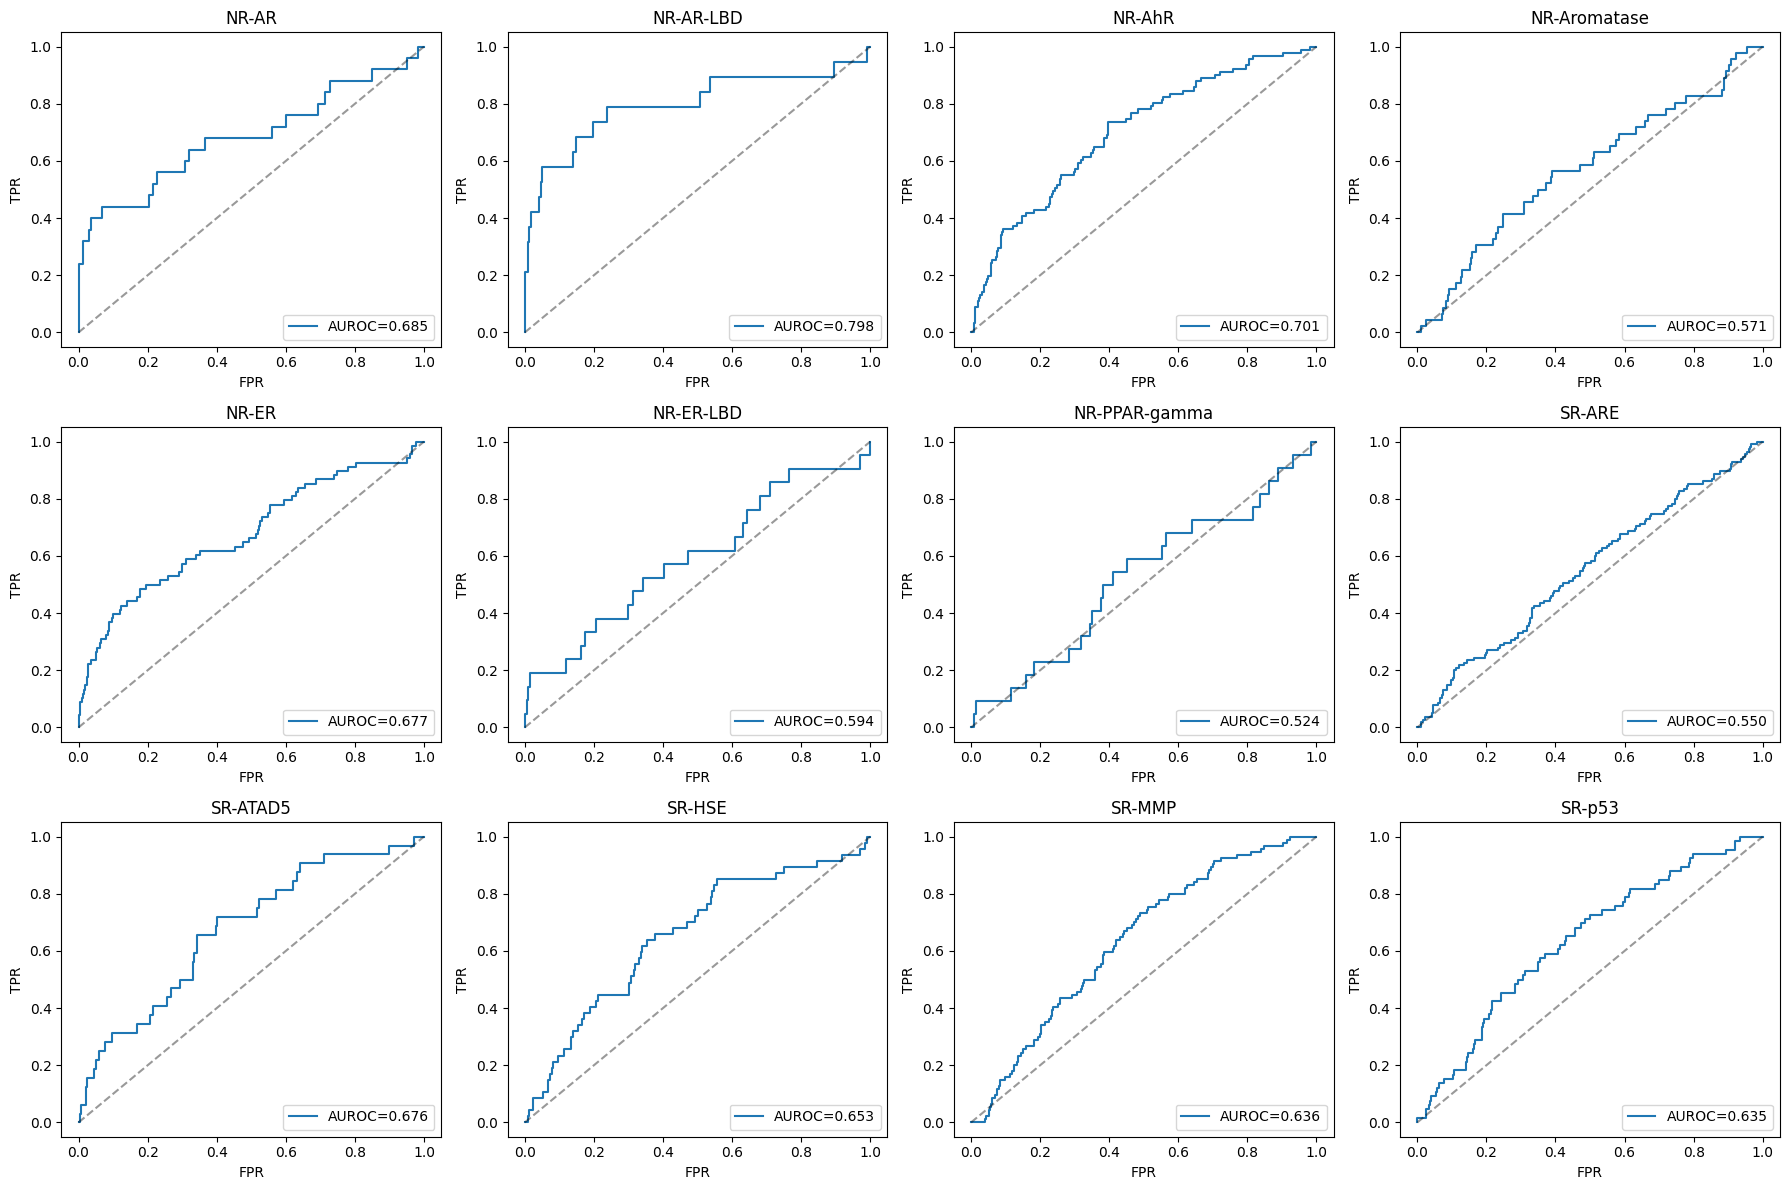

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, task in zip(axes.ravel(), TASKS):
    if task in roc_curves:
        fpr, tpr, auc = roc_curves[task]
        ax.plot(fpr, tpr, label=f"AUROC={auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(task)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(loc="lower right")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

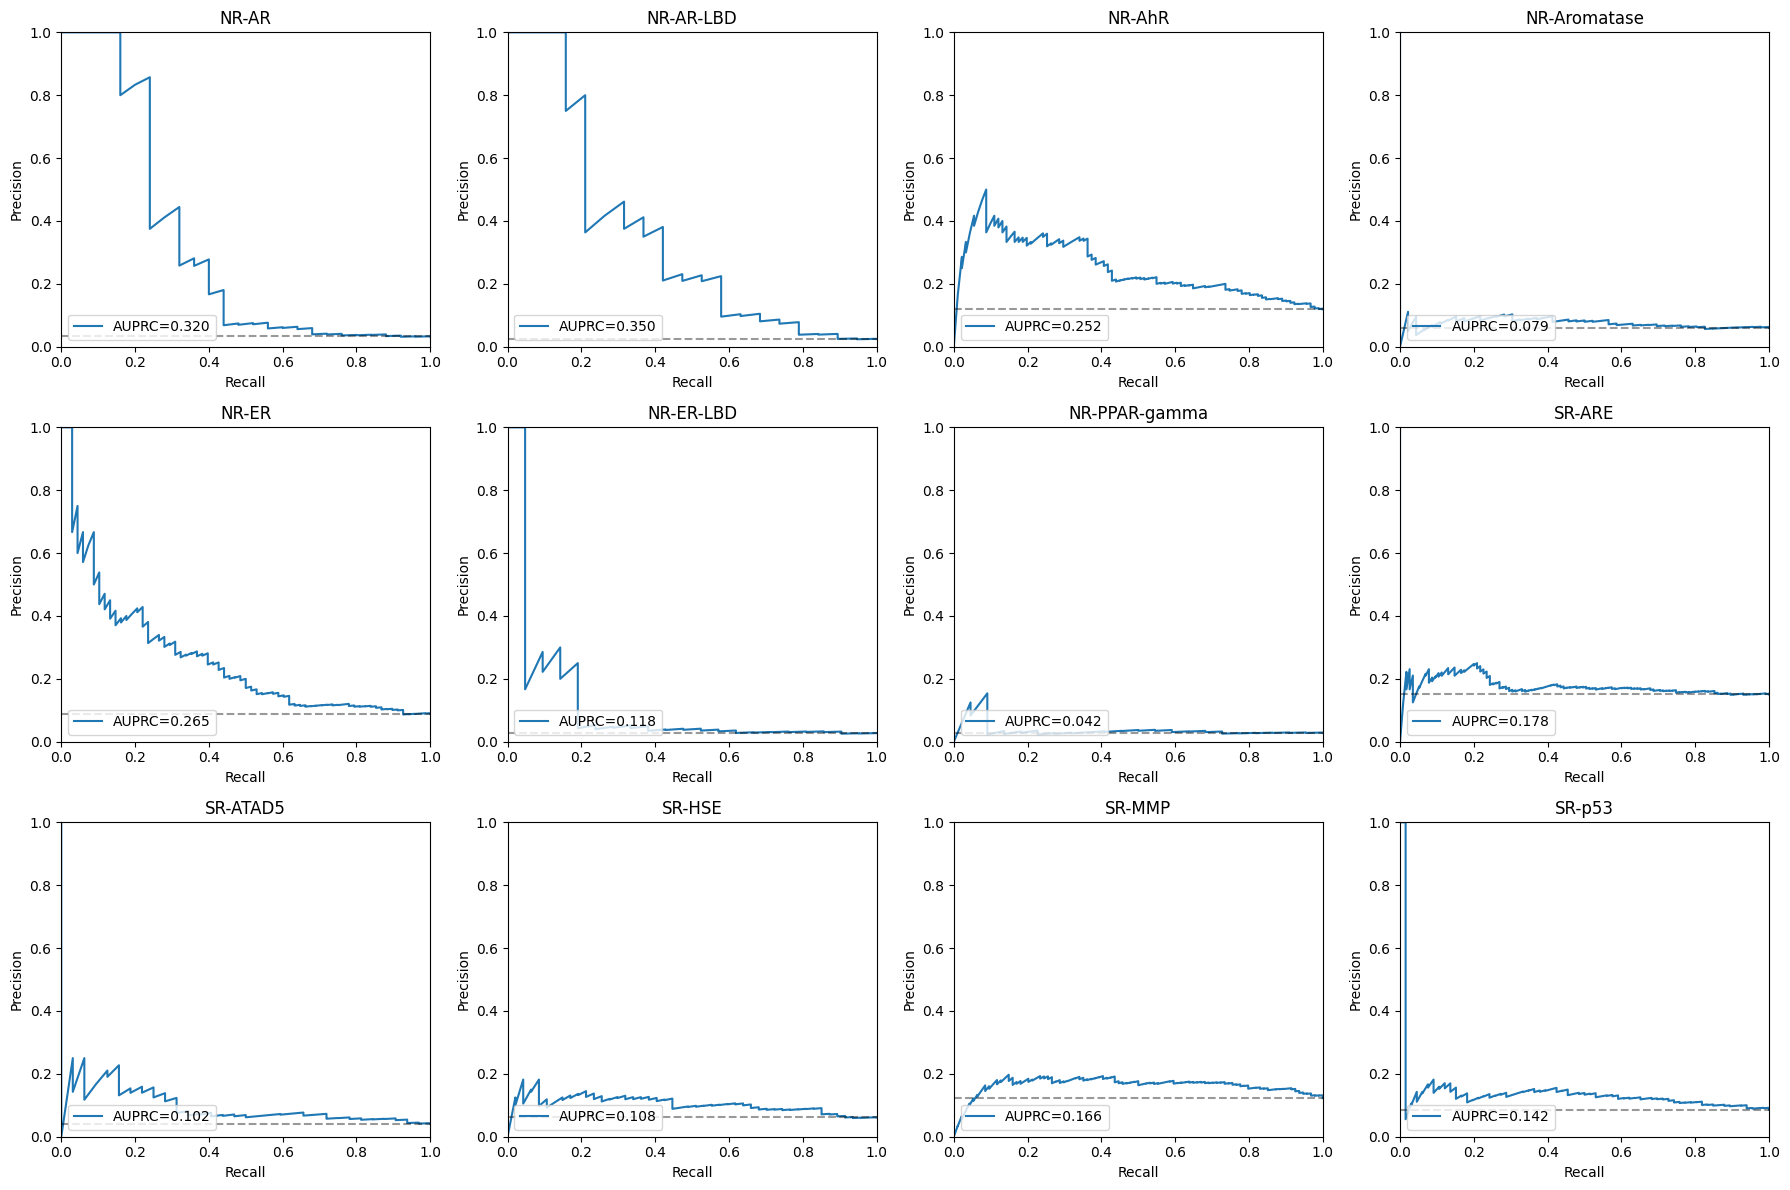

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, task in zip(axes.ravel(), TASKS):
    if task in pr_curves:
        rec, prec, ap, base = pr_curves[task]
        ax.plot(rec, prec, label=f"AUPRC={ap:.3f}")
        ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4)
        ax.set_title(task)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower left")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Tox21 test token accuracy using BEST pretrained checkpoint
TOX21_TEST_PATH = Path("data") / "Test" / "tox21_test_clean.csv"
best_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"

if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

# 1) Load tox21 test SMILES
tox21_test_df = pd.read_csv(TOX21_TEST_PATH)
tox21_test_smiles = tox21_test_df["canonical_smiles"].dropna().astype(str).tolist()
tox21_test_smiles = list(dict.fromkeys(tox21_test_smiles))

# 2) Convert + filter exactly like pretraining pipeline
tox21_test_selfies, tox21_failed = smiles_to_selfies(tox21_test_smiles)
tox21_test_selfies = filter_selfies_len(tox21_test_selfies, max_len=MAX_LEN)
tox21_test_x = encode_list(tox21_test_selfies)

# 3) Load best model weights
bundle = torch.load(best_ckpt_path, map_location=device)
model_best = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
model_best.load_state_dict(bundle["model_state_dict"])

# 4) Evaluate (same token-accuracy computation path as this notebook)
beta_eval = bundle["history"]["beta"][-1] if "history" in bundle and "beta" in bundle["history"] else 1.0
tox21_metrics = evaluate(model_best, tox21_test_x, beta=beta_eval)

print(f"Best checkpoint: {best_ckpt_path.name}")
print(f"Tox21 test SMILES: raw={len(tox21_test_smiles):,} | selfies_ok={len(tox21_test_selfies):,} | failed={tox21_failed:,}")
print(
    f"Tox21 test metrics -> "
    f"total={tox21_metrics['total']:.4f}, "
    f"recon_per_token={tox21_metrics['recon_per_token']:.4f}, "
    f"kl={tox21_metrics['kl']:.4f}, "
    f"token_acc={tox21_metrics['token_acc']:.4f}"
)

Best checkpoint: paper_like_selfies_full_pretrain_seqconv_ce_best.pt
Tox21 test SMILES: raw=783 | selfies_ok=765 | failed=0
Tox21 test metrics -> total=26.0745, recon_per_token=0.6022, kl=0.6945, token_acc=0.8576
